<a href="https://colab.research.google.com/github/AditiNayak-S/anomaly-detection-system/blob/main/anomaly_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_time_series(n_points=1000, n_anomalies=20):

    np.random.seed(42)

    time = np.arange(n_points)

    # normal signal (sine wave + noise)
    signal = np.sin(0.02 * time) + np.random.normal(0, 0.2, n_points)

    # inject anomalies
    anomaly_indices = np.random.choice(n_points, n_anomalies, replace=False)

    signal[anomaly_indices] += np.random.uniform(3, 5, n_anomalies)

    df = pd.DataFrame({
        "time": time,
        "value": signal
    })

    df["is_anomaly"] = 0
    df.loc[anomaly_indices, "is_anomaly"] = 1

    return df

In [2]:
df = generate_time_series()

df.head()

,time,value,is_anomaly
0,0,0.099343,0
1,1,-0.007654,0
2,2,0.169527,0
3,3,0.364570,0
4,4,0.033084,0


In [3]:
def plot_time_series(df):

    plt.figure(figsize=(14,5))

    plt.plot(df["time"], df["value"], label="Normal Signal")

    anomalies = df[df["is_anomaly"] == 1]

    plt.scatter(
        anomalies["time"],
        anomalies["value"],
        color="red",
        label="Anomalies"
    )

    plt.title("Time Series with Anomalies")
    plt.xlabel("Time")
    plt.ylabel("Value")

    plt.legend()

    plt.show()

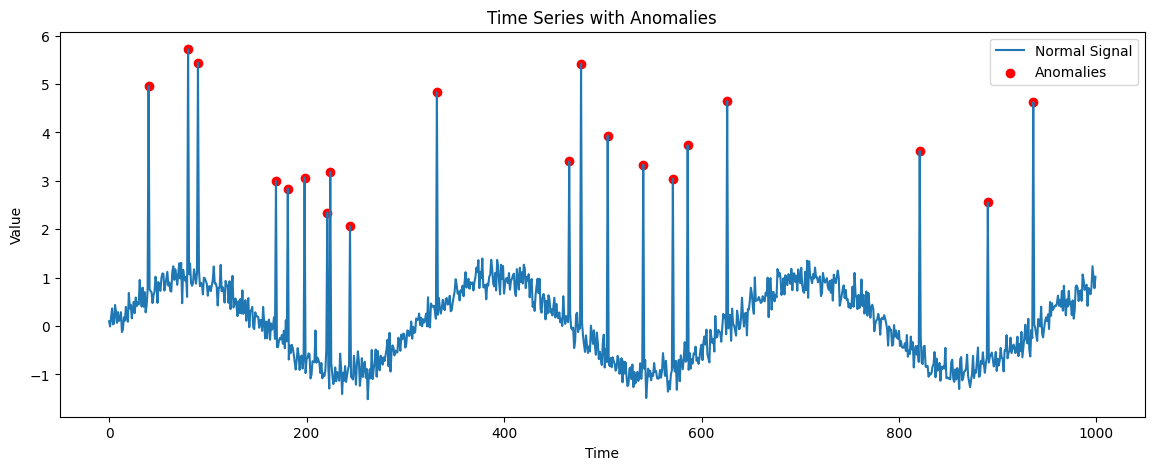

In [4]:
plot_time_series(df)

In [5]:
def create_time_features(df, window=10):

    df = df.copy()

    # Rolling statistics
    df["rolling_mean"] = df["value"].rolling(window=window).mean()
    df["rolling_std"] = df["value"].rolling(window=window).std()

    # Lag features
    df["lag_1"] = df["value"].shift(1)
    df["lag_2"] = df["value"].shift(2)
    df["lag_3"] = df["value"].shift(3)

    # Drop NaN values created by rolling/lagging
    df = df.dropna()

    return df

In [6]:
df_features = create_time_features(df)

df_features.head()

,time,value,is_anomaly,rolling_mean,rolling_std,lag_1,lag_2,lag_3
9,9,0.287542,0,0.179343,0.155056,0.065423,0.293030,0.435555
10,10,0.105986,0,0.180007,0.154688,0.287542,0.065423,0.293030
11,11,0.125084,0,0.193281,0.141968,0.105986,0.287542,0.065423
12,12,0.286095,0,0.204937,0.144563,0.125084,0.105986,0.287542
13,13,-0.125575,0,0.155923,0.165938,0.286095,0.125084,0.105986


In [7]:
def plot_features(df):

    plt.figure(figsize=(14,6))

    plt.plot(df["value"], label="Value")
    plt.plot(df["rolling_mean"], label="Rolling Mean")

    plt.title("Value vs Rolling Mean")

    plt.legend()
    plt.show()

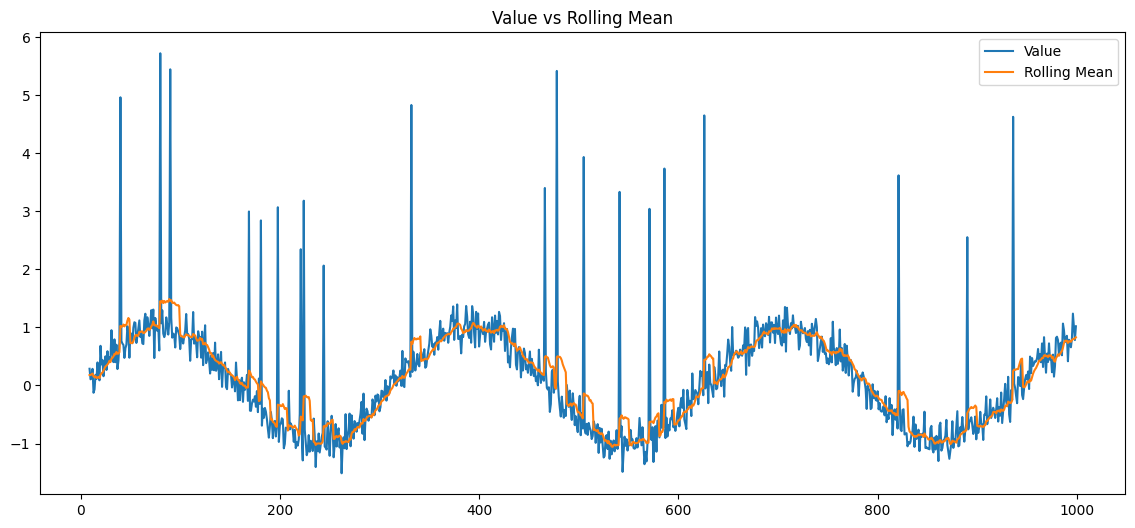

In [8]:
plot_features(df_features)

In [9]:
# Select only feature columns (exclude labels and time)

feature_cols = ["value", "rolling_mean", "rolling_std", "lag_1", "lag_2", "lag_3"]

X = df_features[feature_cols]

In [10]:
from sklearn.ensemble import IsolationForest

def train_isolation_forest(X):

    model = IsolationForest(
        n_estimators=100,
        contamination=0.02,  # expected anomaly ratio
        random_state=42
    )

    model.fit(X)

    return model

In [11]:
iso_model = train_isolation_forest(X)

In [12]:
def get_anomaly_predictions(model, X, df):

    df = df.copy()

    # Prediction: -1 = anomaly, 1 = normal
    preds = model.predict(X)

    df["anomaly_pred"] = preds

    # Convert to 0/1
    df["anomaly_pred"] = df["anomaly_pred"].apply(lambda x: 1 if x == -1 else 0)

    # anomaly score (lower = more anomalous)
    df["anomaly_score"] = model.decision_function(X)

    return df

In [13]:
df_results = get_anomaly_predictions(iso_model, X, df_features)

df_results.head()

,time,value,is_anomaly,rolling_mean,rolling_std,lag_1,lag_2,lag_3,anomaly_pred,anomaly_score
9,9,0.287542,0,0.179343,0.155056,0.065423,0.293030,0.435555,0,0.225433
10,10,0.105986,0,0.180007,0.154688,0.287542,0.065423,0.293030,0,0.227093
11,11,0.125084,0,0.193281,0.141968,0.105986,0.287542,0.065423,0,0.226715
12,12,0.286095,0,0.204937,0.144563,0.125084,0.105986,0.287542,0,0.227481
13,13,-0.125575,0,0.155923,0.165938,0.286095,0.125084,0.105986,0,0.230574


In [14]:
def plot_detected_anomalies(df):

    plt.figure(figsize=(14,5))

    plt.plot(df["time"], df["value"], label="Signal")

    anomalies = df[df["anomaly_pred"] == 1]

    plt.scatter(
        anomalies["time"],
        anomalies["value"],
        color="red",
        label="Detected Anomalies"
    )

    plt.title("Isolation Forest Detected Anomalies")

    plt.legend()
    plt.show()

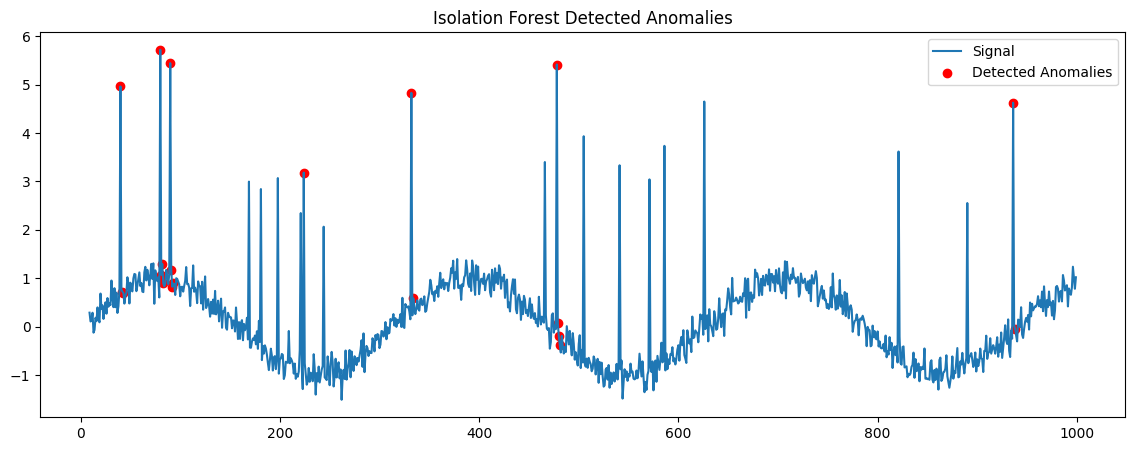

In [15]:
plot_detected_anomalies(df_results)

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    df_results["is_anomaly"],
    df_results["anomaly_pred"]
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       971
           1       0.35      0.35      0.35        20

    accuracy                           0.97       991
   macro avg       0.67      0.67      0.67       991
weighted avg       0.97      0.97      0.97       991



In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

def get_anomaly_models():

    models = {

        "isolation_forest": IsolationForest(
            n_estimators=100,
            contamination=0.02,
            random_state=42
        ),

        "one_class_svm": OneClassSVM(
            kernel="rbf",
            nu=0.02
        ),

        "lof": LocalOutlierFactor(
            n_neighbors=20,
            contamination=0.02
        )
    }

    return models

In [18]:
def train_and_predict_anomalies(models, X, df):

    results = {}

    for name, model in models.items():

        print(f"\nRunning model: {name}")

        df_copy = df.copy()

        if name == "lof":
            preds = model.fit_predict(X)
            scores = model.negative_outlier_factor_
        else:
            model.fit(X)
            preds = model.predict(X)
            scores = model.decision_function(X)

        # Convert predictions: -1 → anomaly (1), 1 → normal (0)
        df_copy["anomaly_pred"] = [1 if p == -1 else 0 for p in preds]

        df_copy["score"] = scores

        results[name] = df_copy

    return results

In [19]:
models = get_anomaly_models()

results_dict = train_and_predict_anomalies(models, X, df_features)


Running model: isolation_forest

Running model: one_class_svm

Running model: lof


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_models(results_dict):

    evaluation = []

    for name, df_res in results_dict.items():

        precision = precision_score(df_res["is_anomaly"], df_res["anomaly_pred"])
        recall = recall_score(df_res["is_anomaly"], df_res["anomaly_pred"])
        f1 = f1_score(df_res["is_anomaly"], df_res["anomaly_pred"])

        evaluation.append({
            "model": name,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

    return pd.DataFrame(evaluation)

In [21]:
evaluation_df = evaluate_models(results_dict)

evaluation_df

,model,precision,recall,f1_score
0,isolation_forest,0.35,0.35,0.350000
1,one_class_svm,0.20,0.25,0.222222
2,lof,0.30,0.30,0.300000


In [22]:
evaluation_df = evaluation_df.sort_values(by="f1_score", ascending=False)

evaluation_df

,model,precision,recall,f1_score
0,isolation_forest,0.35,0.35,0.350000
2,lof,0.30,0.30,0.300000
1,one_class_svm,0.20,0.25,0.222222


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_models(results_dict):

    evaluation = []

    for name, df_res in results_dict.items():

        precision = precision_score(df_res["is_anomaly"], df_res["anomaly_pred"])
        recall = recall_score(df_res["is_anomaly"], df_res["anomaly_pred"])
        f1 = f1_score(df_res["is_anomaly"], df_res["anomaly_pred"])

        evaluation.append({
            "model": name,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

    return pd.DataFrame(evaluation)

In [24]:
evaluation_df = evaluate_models(results_dict)

evaluation_df

,model,precision,recall,f1_score
0,isolation_forest,0.35,0.35,0.350000
1,one_class_svm,0.20,0.25,0.222222
2,lof,0.30,0.30,0.300000


In [25]:
evaluation_df = evaluation_df.sort_values(by="f1_score", ascending=False)

evaluation_df

,model,precision,recall,f1_score
0,isolation_forest,0.35,0.35,0.350000
2,lof,0.30,0.30,0.300000
1,one_class_svm,0.20,0.25,0.222222


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_model_comparison(df):

    df_melted = df.melt(id_vars="model", var_name="metric", value_name="score")

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=df_melted,
        x="model",
        y="score",
        hue="metric"
    )

    plt.title("Anomaly Detection Model Comparison")

    plt.xticks(rotation=30)

    plt.show()

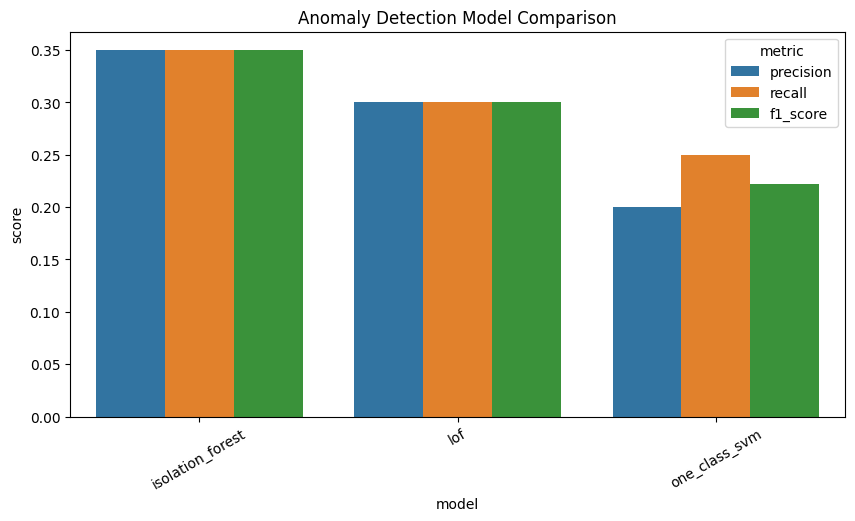

In [27]:
plot_model_comparison(evaluation_df)

In [28]:
from sklearn.preprocessing import MinMaxScaler

def normalize_scores(df, score_column="score"):

    scaler = MinMaxScaler()

    df["normalized_score"] = scaler.fit_transform(df[[score_column]])

    return df

In [31]:
def apply_threshold(df, threshold=0.2):

    df = df.copy()

    # lower score = more anomalous
    df["threshold_pred"] = df["normalized_score"].apply(
        lambda x: 1 if x < threshold else 0
    )

    return df

In [32]:
iso_df = results_dict["isolation_forest"]

iso_df = normalize_scores(iso_df)

iso_df = apply_threshold(iso_df, threshold=0.2)

In [33]:
def plot_threshold_anomalies(df):

    plt.figure(figsize=(14,5))

    plt.plot(df["time"], df["value"], label="Signal")

    anomalies = df[df["threshold_pred"] == 1]

    plt.scatter(
        anomalies["time"],
        anomalies["value"],
        color="red",
        label="Threshold Anomalies"
    )

    plt.title("Threshold-Based Anomaly Detection")

    plt.legend()
    plt.show()

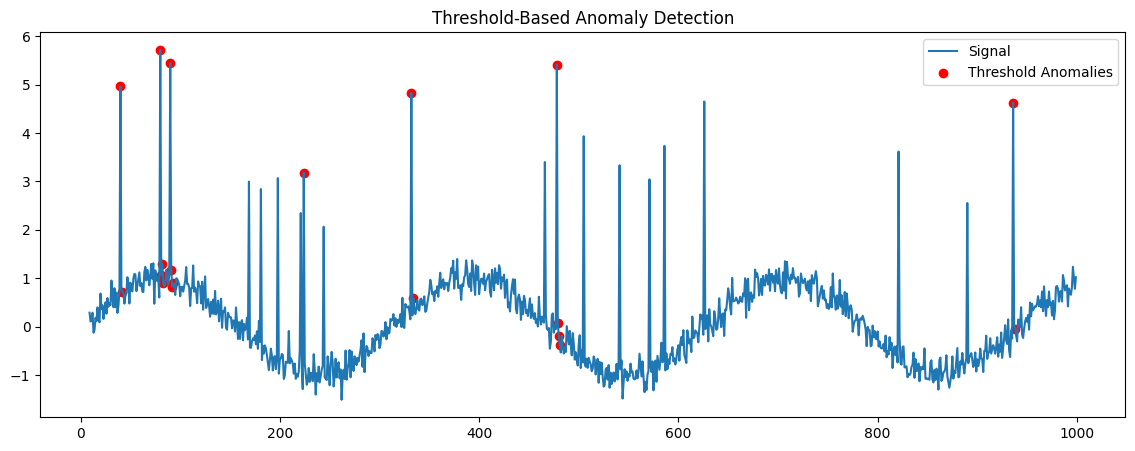

In [34]:
plot_threshold_anomalies(iso_df)

In [35]:
def auto_threshold(df, percentile=5):

    threshold_value = np.percentile(
        df["normalized_score"],
        percentile
    )

    df["auto_pred"] = df["normalized_score"].apply(
        lambda x: 1 if x <= threshold_value else 0
    )

    return df, threshold_value

In [36]:
iso_df, threshold_val = auto_threshold(iso_df, percentile=5)

print("Auto Threshold:", threshold_val)

Auto Threshold: 0.3417353815872134


In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    iso_df["is_anomaly"],
    iso_df["auto_pred"]
))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       971
           1       0.24      0.60      0.34        20

    accuracy                           0.95       991
   macro avg       0.62      0.78      0.66       991
weighted avg       0.98      0.95      0.96       991



In [38]:
stream_df = df_features.reset_index(drop=True)

In [39]:
iso_model = train_isolation_forest(X)

In [40]:
import time

def simulate_streaming(df, model, window_size=50, delay=0.01):

    buffer = []

    predictions = []

    for i in range(len(df)):

        # simulate incoming data
        row = df.iloc[i]
        buffer.append(row)

        # keep only recent window
        if len(buffer) > window_size:
            buffer.pop(0)

        # convert buffer to dataframe
        buffer_df = pd.DataFrame(buffer)

        # only predict if enough data
        if len(buffer_df) >= window_size:

            features = buffer_df[[
                "value",
                "rolling_mean",
                "rolling_std",
                "lag_1",
                "lag_2",
                "lag_3"
            ]]

            pred = model.predict(features.tail(1))[0]

            pred = 1 if pred == -1 else 0

            predictions.append(pred)

            print(f"Time {i} → Anomaly: {pred}")

        else:
            predictions.append(0)

        time.sleep(delay)

    return predictions

In [41]:
stream_preds = simulate_streaming(stream_df, iso_model)

Time 49 → Anomaly: 0
Time 50 → Anomaly: 0
Time 51 → Anomaly: 0
Time 52 → Anomaly: 0
Time 53 → Anomaly: 0
Time 54 → Anomaly: 0
Time 55 → Anomaly: 0
Time 56 → Anomaly: 0
Time 57 → Anomaly: 0
Time 58 → Anomaly: 0
Time 59 → Anomaly: 0
Time 60 → Anomaly: 0
Time 61 → Anomaly: 0
Time 62 → Anomaly: 0
Time 63 → Anomaly: 0
Time 64 → Anomaly: 0
Time 65 → Anomaly: 0
Time 66 → Anomaly: 0
Time 67 → Anomaly: 0
Time 68 → Anomaly: 0
Time 69 → Anomaly: 0
Time 70 → Anomaly: 0
Time 71 → Anomaly: 1
Time 72 → Anomaly: 1
Time 73 → Anomaly: 1
Time 74 → Anomaly: 1
Time 75 → Anomaly: 0
Time 76 → Anomaly: 0
Time 77 → Anomaly: 0
Time 78 → Anomaly: 0
Time 79 → Anomaly: 0
Time 80 → Anomaly: 0
Time 81 → Anomaly: 1
Time 82 → Anomaly: 1
Time 83 → Anomaly: 1
Time 84 → Anomaly: 1
Time 85 → Anomaly: 0
Time 86 → Anomaly: 0
Time 87 → Anomaly: 0
Time 88 → Anomaly: 0
Time 89 → Anomaly: 0
Time 90 → Anomaly: 0
Time 91 → Anomaly: 0
Time 92 → Anomaly: 0
Time 93 → Anomaly: 0
Time 94 → Anomaly: 0
Time 95 → Anomaly: 0
Time 96 → Ano

In [42]:
def plot_streaming_results(df, predictions):

    df_plot = df.copy()
    df_plot["stream_pred"] = predictions

    plt.figure(figsize=(14,5))

    plt.plot(df_plot["time"], df_plot["value"], label="Signal")

    anomalies = df_plot[df_plot["stream_pred"] == 1]

    plt.scatter(
        anomalies["time"],
        anomalies["value"],
        color="red",
        label="Live Detected Anomalies"
    )

    plt.title("Real-Time Anomaly Detection")

    plt.legend()
    plt.show()

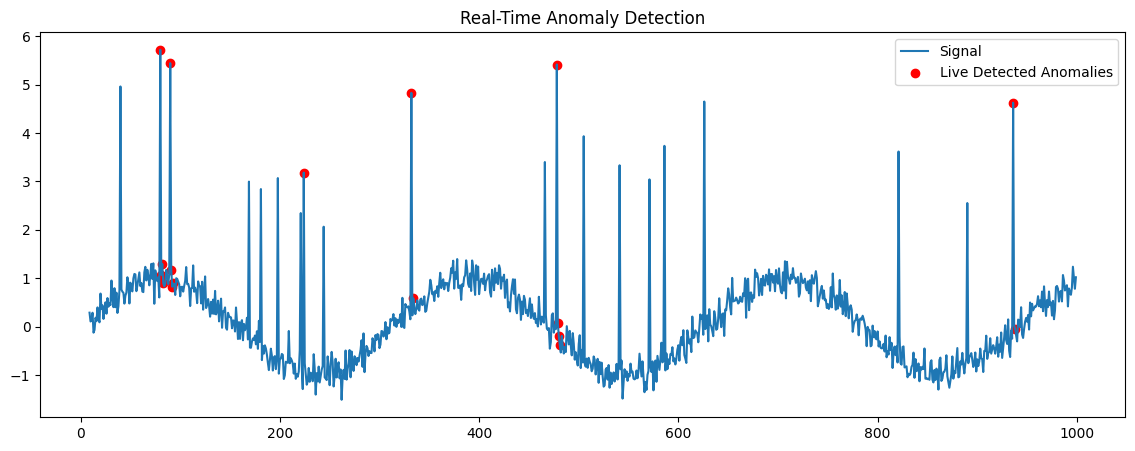

In [43]:
plot_streaming_results(stream_df, stream_preds)

In [44]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.5 MB/s eta 0:00:00


In [56]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

st.title(" Real-Time Anomaly Detection System")

st.write("Upload a dataset or use synthetic data.")
uploaded_file = st.file_uploader("Upload CSV", type=["csv"])

if uploaded_file:
    df = pd.read_csv(uploaded_file)
else:
    st.write("Using synthetic dataset...")

    def generate_data(n=500):
        t = np.arange(n)
        values = np.sin(0.02 * t) + np.random.normal(0, 0.2, n)

        anomalies = np.random.choice(n, 10, replace=False)
        values[anomalies] += np.random.uniform(3,5,10)

        df = pd.DataFrame({
            "time": t,
            "value": values
        })

        return df

    df = generate_data()

# Function to create features
def create_features(df):
    df = df.copy()
    df["rolling_mean"] = df["value"].rolling(10).mean()
    df["rolling_std"] = df["value"].rolling(10).std()
    df["lag_1"] = df["value"].shift(1)
    df["lag_2"] = df["value"].shift(2)
    df = df.dropna()
    return df

df = create_features(df) # Apply feature creation to the dataframe

# Define feature columns and train model
feature_cols = ["value","rolling_mean","rolling_std","lag_1","lag_2"]
model = IsolationForest(contamination=0.02)
model.fit(df[feature_cols])

start_streaming = st.button("▶ Start Streaming")

if start_streaming:
    chart = st.empty()
    alert_box = st.empty()

    data_buffer = []

    for i in range(len(df)):
        row = df.iloc[i]
        data_buffer.append(row)

        buffer_df = pd.DataFrame(data_buffer)

        if len(buffer_df) > 20:
            X_live = buffer_df[feature_cols].tail(1)
            pred = model.predict(X_live)[0]
            is_anomaly = 1 if pred == -1 else 0

            # 🚨 ALERT SYSTEM
            if is_anomaly == 1:
                alert_box.error(f"🚨 Anomaly detected at time {row['time']}")
            else:
                alert_box.success("System Normal")

        # Plot live data
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(buffer_df["time"], buffer_df["value"], label="Signal")

        # Ensure anomalies are from the current buffer_df for plotting
        anomalies_to_plot = buffer_df[buffer_df['time'].isin(buffer_df.loc[buffer_df.index < len(data_buffer), 'time'])] # This line might need adjustment based on how anomalies are stored.

        ax.scatter(
            buffer_df["time"],
            buffer_df["value"],
            c="blue"
        )

        chart.pyplot(fig)

        time.sleep(0.05)


Overwriting app.py


In [51]:
def create_features(df):

    df = df.copy()

    df["rolling_mean"] = df["value"].rolling(10).mean()
    df["rolling_std"] = df["value"].rolling(10).std()

    df["lag_1"] = df["value"].shift(1)
    df["lag_2"] = df["value"].shift(2)

    df = df.dropna()

    return df

df = create_features(df)

In [52]:
feature_cols = ["value","rolling_mean","rolling_std","lag_1","lag_2"]

model = IsolationForest(contamination=0.02)

model.fit(df[feature_cols])

IsolationForest(contamination=0.02)

In [65]:
!pip install pyngrok
!ngrok config add-authtoken 3B4oSmj8TTY0uiKrQnilDqIXAJ0_76qwj6uBNf4P8TN6QD1Dg

!streamlit run app.py &>/dev/null &

from pyngrok import ngrok
print(ngrok.connect(8501))

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
NgrokTunnel: "https://distal-homeopathically-mikayla.ngrok-free.dev" -> "http://localhost:8501"
